In [1]:
!pip install xgboost lightgbm catboost

# 1) Import the libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    balanced_accuracy_score,
    roc_auc_score,roc_curve,
    precision_recall_curve,average_precision_score
)
# Classification models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

from sklearn.naive_bayes import GaussianNB

from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier,
    HistGradientBoostingClassifier,
    VotingClassifier,
    StackingClassifier
)

from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier


# 2) Read the data

In [3]:
df= pd.read_csv('/kaggle/input/playground-series-s6e2/train.csv')

In [4]:
df.head()

,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,0,58,1,4,152,239,0,0,158,1,3.6,2,2,7,Presence
1,1,52,1,1,125,325,0,2,171,0,0.0,1,0,3,Absence
2,2,56,0,2,160,188,0,2,151,0,0.0,1,0,3,Absence
3,3,44,0,3,134,229,0,2,150,0,1.0,2,0,3,Absence
4,4,58,1,4,140,234,0,2,125,1,3.8,2,3,3,Presence


# 3) Exploratory data analysis

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 15 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       630000 non-null  int64  
 1   Age                      630000 non-null  int64  
 2   Sex                      630000 non-null  int64  
 3   Chest pain type          630000 non-null  int64  
 4   BP                       630000 non-null  int64  
 5   Cholesterol              630000 non-null  int64  
 6   FBS over 120             630000 non-null  int64  
 7   EKG results              630000 non-null  int64  
 8   Max HR                   630000 non-null  int64  
 9   Exercise angina          630000 non-null  int64  
 10  ST depression            630000 non-null  float64
 11  Slope of ST              630000 non-null  int64  
 12  Number of vessels fluro  630000 non-null  int64  
 13  Thallium                 630000 non-null  int64  
 14  Hear

In [6]:
df = df.drop(['id'] , axis = 1)

In [7]:
df.describe()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium
count,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000
mean,54.136706,0.714735,3.312752,130.497433,245.011814,0.079987,0.981660,152.816763,0.273725,0.716028,1.455871,0.451040,4.618873
std,8.256301,0.451541,0.851615,14.975802,33.681581,0.271274,0.998783,19.112927,0.445870,0.948472,0.545192,0.798549,1.950007
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000
25%,48.000000,0.000000,3.000000,120.000000,223.000000,0.000000,0.000000,142.000000,0.000000,0.000000,1.000000,0.000000,3.000000
50%,54.000000,1.000000,4.000000,130.000000,243.000000,0.000000,0.000000,157.000000,0.000000,0.100000,1.000000,0.000000,3.000000
75%,60.000000,1.000000,4.000000,140.000000,269.000000,0.000000,2.000000,166.000000,1.000000,1.400000,2.000000,1.000000,7.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000


In [8]:
df.isnull().sum()

Age                        0
Sex                        0
Chest pain type            0
BP                         0
Cholesterol                0
FBS over 120               0
EKG results                0
Max HR                     0
Exercise angina            0
ST depression              0
Slope of ST                0
Number of vessels fluro    0
Thallium                   0
Heart Disease              0
dtype: int64

In [9]:
X=df.drop('Heart Disease',axis =1)
y= df[['Heart Disease']]

In [10]:
y.head()

,Heart Disease
0,Presence
1,Absence
2,Absence
3,Absence
4,Presence


# 4) LabelEncoding

In [11]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

In [12]:
df['Heart Disease'] = le.fit_transform(df['Heart Disease'])
df.head()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,58,1,4,152,239,0,0,158,1,3.6,2,2,7,1
1,52,1,1,125,325,0,2,171,0,0.0,1,0,3,0
2,56,0,2,160,188,0,2,151,0,0.0,1,0,3,0
3,44,0,3,134,229,0,2,150,0,1.0,2,0,3,0
4,58,1,4,140,234,0,2,125,1,3.8,2,3,3,1


In [13]:
print(dict(zip(le.classes_, le.transform(le.classes_))))

{'Absence': np.int64(0), 'Presence': np.int64(1)}


# 5) Visualization

<Axes: >

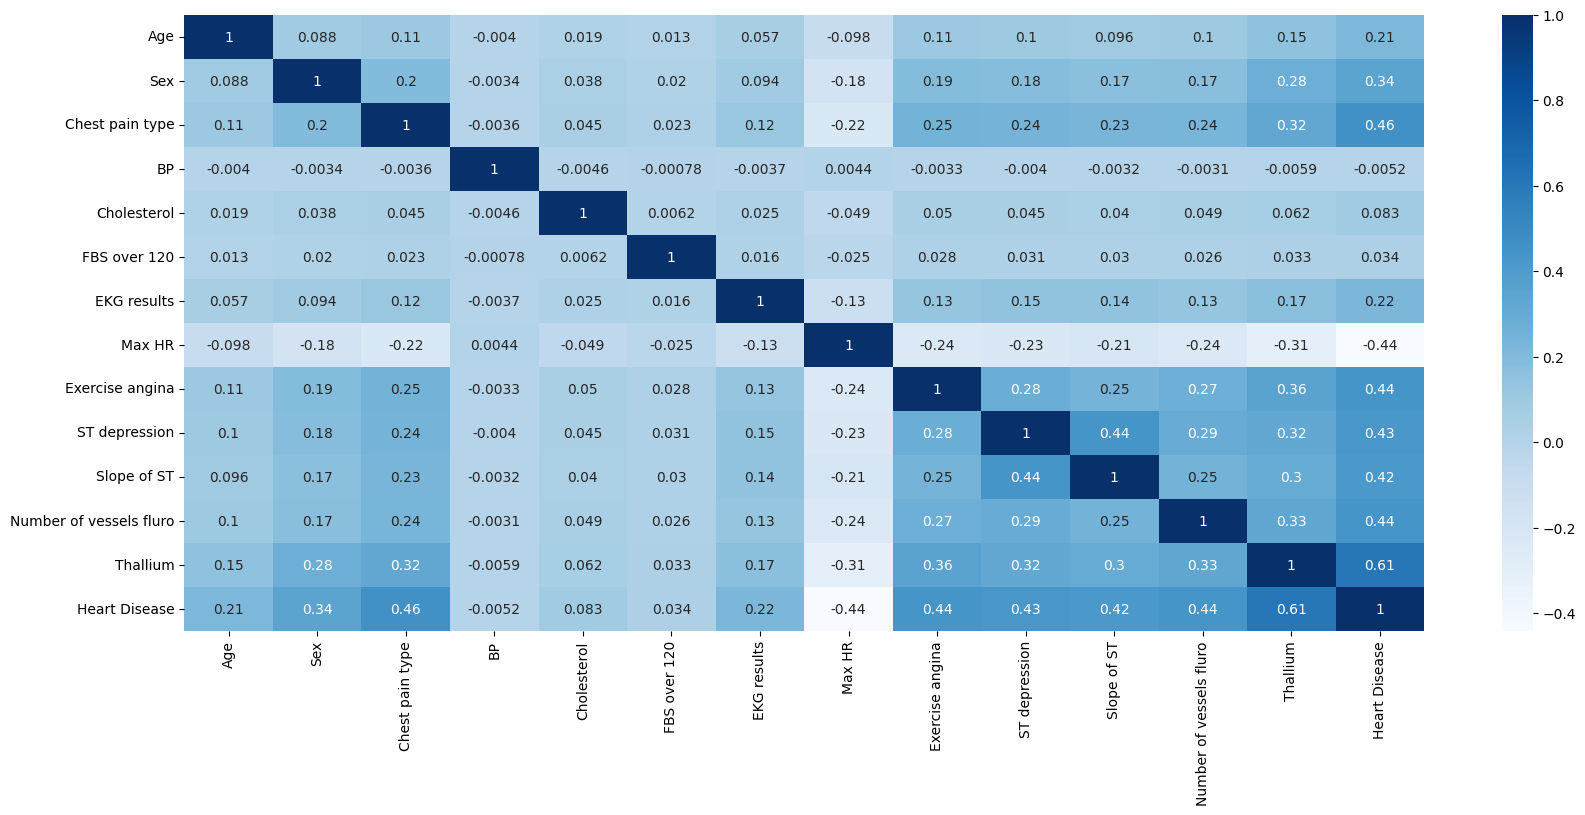

In [14]:
plt.figure(figsize=(20,8))
sns.heatmap(df.corr(),annot=True,cmap='Blues',fmt='0.2g')

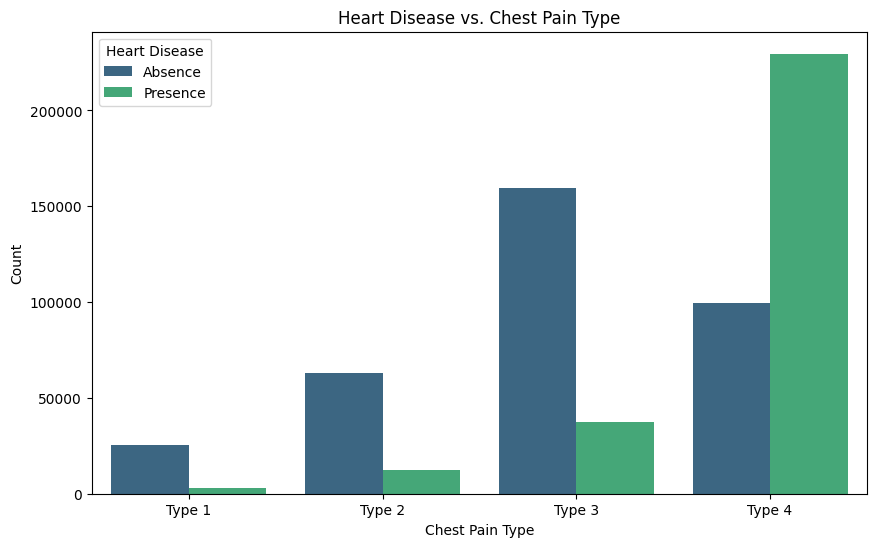

In [15]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Chest pain type', hue='Heart Disease', palette='viridis')
plt.title('Heart Disease vs. Chest Pain Type')
plt.xlabel('Chest Pain Type')
plt.ylabel('Count')
plt.xticks(ticks=[0, 1, 2, 3], labels=['Type 1', 'Type 2', 'Type 3', 'Type 4'])
plt.legend(title='Heart Disease', labels=['Absence', 'Presence'])
plt.show()

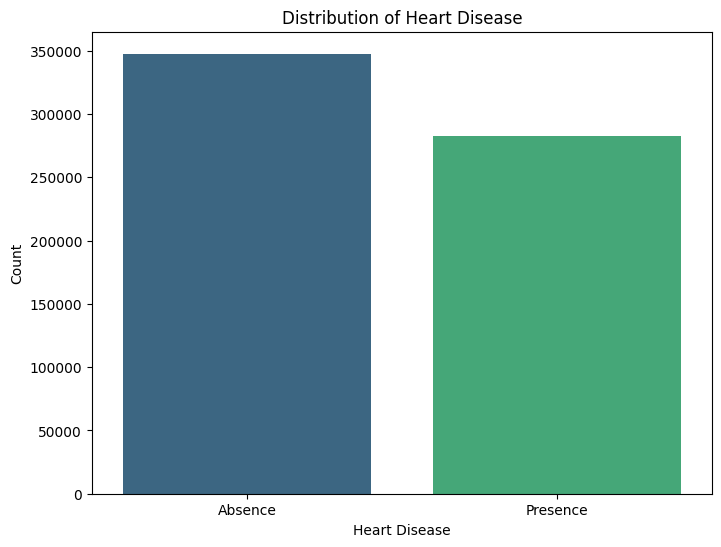

In [16]:
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='Heart Disease', hue='Heart Disease', palette='viridis', legend=False)
plt.title('Distribution of Heart Disease')
plt.xlabel('Heart Disease')
plt.ylabel('Count')
plt.xticks(ticks=[0, 1], labels=['Absence', 'Presence'])
plt.show()

# 6) Train Test Split

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (504000, 13)
X_test shape: (126000, 13)
y_train shape: (504000, 1)
y_test shape: (126000, 1)


# 7) Training Process

In [18]:
models = {

    # Linear
    "Logistic Regression": LogisticRegression(max_iter=2000, random_state=1),

    # Distance-based
    #"KNN": KNeighborsClassifier(n_neighbors=5),

    # SVM
    #"SVC": SVC(probability=True, random_state=1),

    # Tree
    #"Decision Tree": DecisionTreeClassifier(random_state=1),

    # Naive Bayes
    #"Naive Bayes": GaussianNB(),

    # Bagging Based
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=1),
    "Extra Trees": ExtraTreesClassifier(n_estimators=100, random_state=1),

    # Boosting
    "AdaBoost": AdaBoostClassifier(random_state=1),
    "Gradient Boosting": GradientBoostingClassifier(random_state=1),
    "Hist Gradient Boosting": HistGradientBoostingClassifier(random_state=1),

    # External Boosting Libraries
    "XGBoost": XGBClassifier(eval_metric='logloss', random_state=1, use_label_encoder=False),
    "CatBoost": CatBoostClassifier(verbose=0, random_state=1),
    "LightGBM": LGBMClassifier(random_state=1)
}

In [19]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder

# 1. سد الفراغات في الـ X (عشان الـ Logistic والموديلات التانية متزعلش)
imputer = SimpleImputer(strategy='median')
X_train_fixed = imputer.fit_transform(X_train)
X_test_fixed = imputer.transform(X_test)

# 2. تحويل الـ y لأرقام (عشان Precision و Recall والـ Error اللي طلعلك)
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

print("✅ Data is ready! 'Absence' is 0 and 'Presence' is 1")

✅ Data is ready! 'Absence' is 0 and 'Presence' is 1


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:129: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, dtype=self.classes_.dtype, warn=True)


  0%|          | 0/9 [00:00<?, ?it/s]

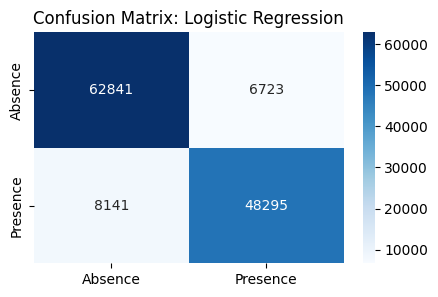

 11%|█         | 1/9 [01:19<10:34, 79.28s/it]


Classification Report for Logistic Regression:

              precision    recall  f1-score   support

     Absence       0.89      0.90      0.89     69564
    Presence       0.88      0.86      0.87     56436

    accuracy                           0.88    126000
   macro avg       0.88      0.88      0.88    126000
weighted avg       0.88      0.88      0.88    126000

ROC-AUC: 0.95


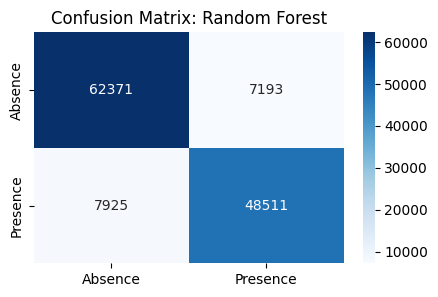


Classification Report for Random Forest:

              precision    recall  f1-score   support

     Absence       0.89      0.90      0.89     69564
    Presence       0.87      0.86      0.87     56436

    accuracy                           0.88    126000
   macro avg       0.88      0.88      0.88    126000
weighted avg       0.88      0.88      0.88    126000



 22%|██▏       | 2/9 [02:33<08:53, 76.29s/it]

ROC-AUC: 0.95


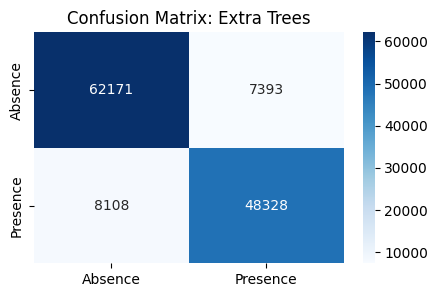


Classification Report for Extra Trees:

              precision    recall  f1-score   support

     Absence       0.88      0.89      0.89     69564
    Presence       0.87      0.86      0.86     56436

    accuracy                           0.88    126000
   macro avg       0.88      0.88      0.88    126000
weighted avg       0.88      0.88      0.88    126000



 33%|███▎      | 3/9 [03:52<07:45, 77.66s/it]

ROC-AUC: 0.94


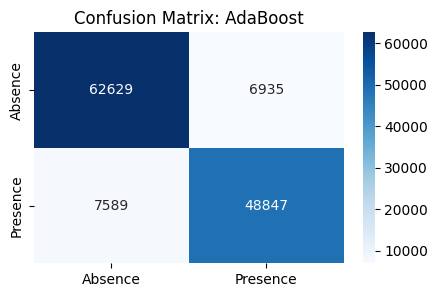


Classification Report for AdaBoost:

              precision    recall  f1-score   support

     Absence       0.89      0.90      0.90     69564
    Presence       0.88      0.87      0.87     56436

    accuracy                           0.88    126000
   macro avg       0.88      0.88      0.88    126000
weighted avg       0.88      0.88      0.88    126000



 44%|████▍     | 4/9 [04:05<04:19, 51.88s/it]

ROC-AUC: 0.95


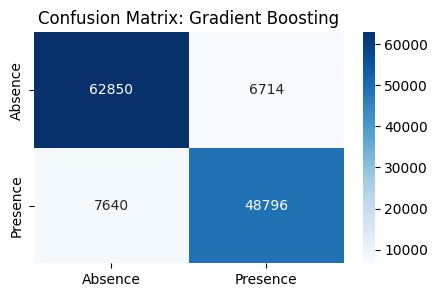


Classification Report for Gradient Boosting:

              precision    recall  f1-score   support

     Absence       0.89      0.90      0.90     69564
    Presence       0.88      0.86      0.87     56436

    accuracy                           0.89    126000
   macro avg       0.89      0.88      0.88    126000
weighted avg       0.89      0.89      0.89    126000



 56%|█████▌    | 5/9 [04:54<03:23, 50.83s/it]

ROC-AUC: 0.95


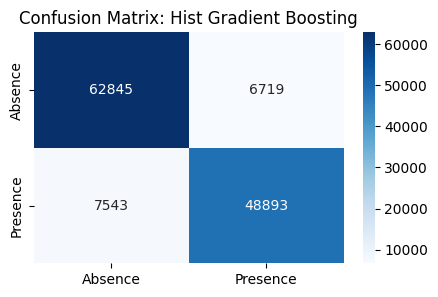


Classification Report for Hist Gradient Boosting:

              precision    recall  f1-score   support

     Absence       0.89      0.90      0.90     69564
    Presence       0.88      0.87      0.87     56436

    accuracy                           0.89    126000
   macro avg       0.89      0.88      0.89    126000
weighted avg       0.89      0.89      0.89    126000



 67%|██████▋   | 6/9 [05:02<01:49, 36.33s/it]

ROC-AUC: 0.95


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [04:34:04] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


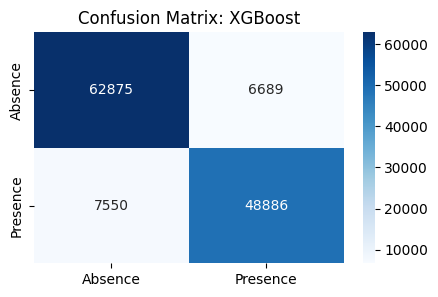


Classification Report for XGBoost:

              precision    recall  f1-score   support

     Absence       0.89      0.90      0.90     69564
    Presence       0.88      0.87      0.87     56436

    accuracy                           0.89    126000
   macro avg       0.89      0.89      0.89    126000
weighted avg       0.89      0.89      0.89    126000



 78%|███████▊  | 7/9 [05:05<00:51, 25.58s/it]

ROC-AUC: 0.95


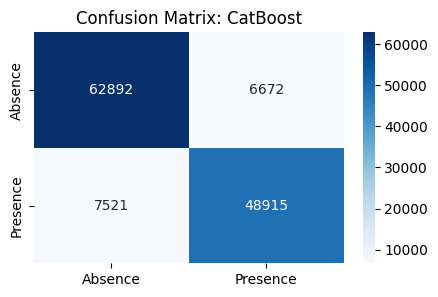

 89%|████████▉ | 8/9 [05:54<00:32, 32.80s/it]


Classification Report for CatBoost:

              precision    recall  f1-score   support

     Absence       0.89      0.90      0.90     69564
    Presence       0.88      0.87      0.87     56436

    accuracy                           0.89    126000
   macro avg       0.89      0.89      0.89    126000
weighted avg       0.89      0.89      0.89    126000

ROC-AUC: 0.96
[LightGBM] [Info] Number of positive: 226018, number of negative: 277982
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.028816 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 414
[LightGBM] [Info] Number of data points in the train set: 504000, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.448448 -> initscore=-0.206942
[LightGBM] [Info] Start training from score -0.206942


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


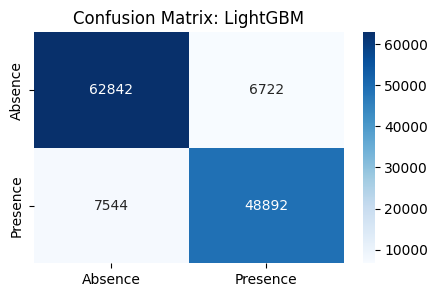


Classification Report for LightGBM:

              precision    recall  f1-score   support

     Absence       0.89      0.90      0.90     69564
    Presence       0.88      0.87      0.87     56436

    accuracy                           0.89    126000
   macro avg       0.89      0.88      0.89    126000
weighted avg       0.89      0.89      0.89    126000



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
100%|██████████| 9/9 [06:00<00:00, 40.03s/it]

ROC-AUC: 0.95


In [20]:
results = {}

for name, model in tqdm(models.items()):
    # التدريب على النسخة اللي مفيهاش NaNs ومتحولة أرقام
    model.fit(X_train_fixed, y_train_encoded)

    train_pred = model.predict(X_train_fixed)
    test_pred  = model.predict(X_test_fixed)

    # الحسابات دلوقتي هتشتغل لأن كل الأطراف أرقام (0 و 1)
    results[name] = {
        "Train Accuracy": accuracy_score(y_train_encoded, train_pred),
        "Test Accuracy": accuracy_score(y_test_encoded, test_pred),
        "Train Precision": precision_score(y_train_encoded, train_pred),
        "Test Precision": precision_score(y_test_encoded, test_pred),
        "Train Recall": recall_score(y_train_encoded, train_pred),
        "Test Recall": recall_score(y_test_encoded, test_pred),
        "Train F1 Score": f1_score(y_train_encoded, train_pred),
        "Test F1 Score": f1_score(y_test_encoded, test_pred)
    }

    # Confusion Matrix الرسم بالشكل اللي إنت بتحبه
    cm = confusion_matrix(y_test_encoded, test_pred)
    plt.figure(figsize=(5,3))
    sns.heatmap(cm, annot=True, fmt="d", cmap='Blues', 
                xticklabels=['Absence','Presence'], 
                yticklabels=['Absence','Presence'])
    plt.title(f'Confusion Matrix: {name}')
    plt.show()

    # تقرير التصنيف الكامل
    print(f"\nClassification Report for {name}:\n")
    print(classification_report(y_test_encoded, test_pred, target_names=['Absence','Presence']))

    # حساب الـ ROC-AUC لو الموديل بيدعم الاحتمالات
    if hasattr(model, "predict_proba"):
        y_pred_prob = model.predict_proba(X_test_fixed)[:, 1]
        print(f"ROC-AUC: {roc_auc_score(y_test_encoded, y_pred_prob):.2f}")

In [21]:
results_df = pd.DataFrame(results).T
results_df = results_df.sort_values(by="Test F1 Score", ascending=False)

In [22]:
results_df

,Train Accuracy,Test Accuracy,Train Precision,Test Precision,Train Recall,Test Recall,Train F1 Score,Test F1 Score
CatBoost,0.894177,0.887357,0.888843,0.879972,0.873227,0.866734,0.880966,0.873303
XGBoost,0.892665,0.886992,0.886713,0.879640,0.872068,0.866220,0.879329,0.872879
Hist Gradient Boosting,0.889111,0.886810,0.882628,0.879181,0.868179,0.866344,0.875343,0.872715
LightGBM,0.889181,0.886778,0.882588,0.879131,0.868409,0.866326,0.875441,0.872682
Gradient Boosting,0.887623,0.886079,0.881621,0.879049,0.865643,0.864625,0.873559,0.871777
AdaBoost,0.885720,0.884730,0.878316,0.875677,0.865006,0.865529,0.871610,0.870573
Logistic Regression,0.883429,0.882032,0.880109,0.877804,0.856768,0.855748,0.868281,0.866636
Random Forest,0.999976,0.880016,0.999982,0.870871,0.999965,0.859575,0.999973,0.865186
Extra Trees,1.000000,0.876976,1.000000,0.867321,1.000000,0.856333,1.000000,0.861792


In [23]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='median')
imputer.fit(X_train) 
print("✅ Imputer is ready!")

✅ Imputer is ready!


In [24]:
test_df = pd.read_csv('/kaggle/input/playground-series-s6e2/test.csv')

X_test_final = test_df.drop(columns=['id', 'ID'], errors='ignore')

# 3. ملء الفراغات (الخانات الفاضية) باستخدام الـ imputer اللي عملنا له fit
X_test_imputed = imputer.transform(X_test_final)

print("✅ Data cleaning and Imputation done!")

✅ Data cleaning and Imputation done!


In [25]:
from sklearn.preprocessing import MinMaxScaler

# Impute X_train first, as the imputer was fitted on X_train
X_train_imputed = imputer.transform(X_train)

# Initialize and fit the MinMaxScaler on the imputed training data
my_scaler = MinMaxScaler()
my_scaler.fit(X_train_imputed)

print("✅ MinMaxScaler is defined and fitted on X_train_imputed!")

✅ MinMaxScaler is defined and fitted on X_train_imputed!


In [27]:
best_model = models["CatBoost"]

final_predictions = best_model.predict(X_test_imputed)

print("✅ Model is ready and predictions are done!")

✅ Model is ready and predictions are done!


In [28]:
import pandas as pd

# 1. قراءة قالب التسليم (لازم يكون عندك ملف اسمه sample_submission.csv)
submission = pd.read_csv('/kaggle/input/playground-series-s6e2/sample_submission.csv')

# 2. استبدال عمود التوقعات بالنتائج اللي الموديل طلعها
# ملحوظة: تأكد إن اسم العمود في ملف الـ sample هو 'Heart Disease'
submission['Heart Disease'] = final_predictions

# 3. حفظ الملف النهائي
submission.to_csv('final_submission.csv', index=False)

print("🔥 Done! Your file 'final_submission.csv' is ready to be uploaded.")

🔥 Done! Your file 'final_submission.csv' is ready to be uploaded.
